# Eksperimen — Heart Failure Clinical Records

**Proyek:** Membangun Sistem Machine Learning (Dicoding) — tahap eksperimen & preprocessing.

| | |
|---|---|
| **Dataset** | `data/raw/heart_failure_clinical_records_dataset.csv` (299 baris × 13 kolom) |
| **Sumber** | UCI — Heart Failure Clinical Records |
| **Tugas** | Klasifikasi biner — memprediksi kematian pasien selama masa follow-up |
| **Target** | `DEATH_EVENT` → distandarkan menjadi `death_event` |
| **Output** | `data/processed/` (train/test CSV + preprocessor + metadata) |

## Alur notebook

1. Setup & muat data mentah (deteksi file otomatis)
2. EDA singkat — struktur, missing value, duplikat, distribusi target, korelasi
3. Penentuan kolom target beserta asumsinya
4. Penjelasan keputusan preprocessing
5. Menjalankan pipeline preprocessing
6. Verifikasi hasil & penyimpanan ke `data/processed/`

> **Catatan penting:** seluruh logika preprocessing berada di [`experiment/automate.py`](../automate.py)
> dan notebook ini **meng-import** modul tersebut. Dengan begitu notebook dan skrip otomatis
> dijamin memakai logika yang **persis sama** — tidak ada kode yang diduplikasi dan berpotensi
> menjadi tidak sinkron. Skrip yang sama dapat dijalankan langsung dengan `python experiment/automate.py`.

## 1. Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Notebook berada di experiment/notebooks/, jadi root proyek ada 2 level di atas.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data" / "raw").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Agar `import automate` dapat menemukan experiment/automate.py.
sys.path.insert(0, str(PROJECT_ROOT / "experiment"))
import automate  # noqa: E402  (seluruh logika preprocessing ada di sini)

RANDOM_STATE = automate.RANDOM_STATE  # 42 — seed tunggal untuk semua langkah acak
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

print("Project root :", PROJECT_ROOT)
print("Random state :", RANDOM_STATE)

Project root : D:\DocDante\Kuliah\Lomba\BI-2026\Sistem Machine Learning\Submission
Random state : 42


## 2. Muat data mentah

File dataset dicari **secara otomatis** di `data/raw/` (`automate.find_dataset`): semua file
berekstensi `.csv`/`.xlsx`/`.xls` dikumpulkan lalu yang berukuran terbesar dipilih. Arsip `.zip`
yang ada di folder tersebut diabaikan karena ekstensinya tidak didukung.

In [2]:
raw_path = automate.find_dataset(PROJECT_ROOT / "data" / "raw")
df_raw = automate.load_dataset(raw_path)

print("File   :", raw_path.relative_to(PROJECT_ROOT))
print("Ukuran :", df_raw.shape)
df_raw.head()

File   : data\raw\heart_failure_clinical_records_dataset.csv
Ukuran : (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. EDA singkat

### 3.1 Struktur, tipe data, dan kualitas data

In [3]:
info = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
    "pct_missing": (df_raw.isna().mean() * 100).round(2),
})
print("Total missing value :", int(df_raw.isna().sum().sum()))
print("Baris duplikat      :", int(df_raw.duplicated().sum()))
info

Total missing value : 0
Baris duplikat      : 0


,dtype,n_unique,n_missing,pct_missing
age,float64,47,0,0.0
anaemia,int64,2,0,0.0
creatinine_phosphokinase,int64,208,0,0.0
diabetes,int64,2,0,0.0
ejection_fraction,int64,17,0,0.0
high_blood_pressure,int64,2,0,0.0
platelets,float64,176,0,0.0
serum_creatinine,float64,40,0,0.0
serum_sodium,int64,27,0,0.0
sex,int64,2,0,0.0


In [4]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.83,11.89,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.43,0.50,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.84,970.29,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.08,11.83,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.35,0.48,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.03,97804.24,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.39,1.03,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.63,4.41,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0


**Bacaan cepat:**

- Tidak ada *missing value* dan tidak ada baris duplikat — dataset ini memang sudah bersih.
- Semua kolom bertipe numerik; lima di antaranya (`anaemia`, `diabetes`, `high_blood_pressure`,
  `sex`, `smoking`) sebenarnya adalah **indikator biner 0/1** yang sudah ter-encode.
- Skala antar fitur kontinu sangat timpang: `platelets` berkisar ratusan ribu sementara
  `serum_creatinine` bernilai satuan → penskalaan diperlukan.
- `creatinine_phosphokinase`, `platelets`, dan `serum_creatinine` sangat *skewed* (mean ≫ median).

### 3.2 Distribusi target

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Proporsi:
DEATH_EVENT
0    0.679
1    0.321
Name: count, dtype: float64


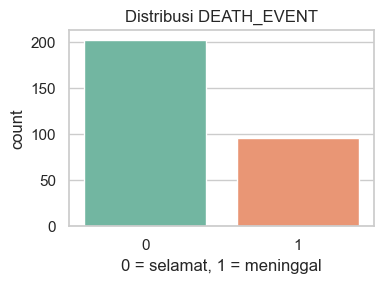

In [5]:
target_col_raw = "DEATH_EVENT"
counts = df_raw[target_col_raw].value_counts().sort_index()
print(counts)
print("\nProporsi:")
print((counts / len(df_raw)).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=df_raw[target_col_raw], hue=df_raw[target_col_raw], palette="Set2", legend=False, ax=ax)
ax.set_title("Distribusi DEATH_EVENT")
ax.set_xlabel("0 = selamat, 1 = meninggal")
plt.tight_layout()
plt.show()

Kelas tidak seimbang (kurang lebih **68% : 32%**), tapi belum ekstrem. Karena itu:

- pembagian train/test dilakukan **stratified** agar proporsi kelas terjaga di kedua split;
- *resampling* (SMOTE/undersampling) **tidak** dilakukan pada tahap preprocessing — penanganan
  ketidakseimbangan lebih tepat ditangani saat pemodelan (mis. `class_weight="balanced"`)
  sehingga data hasil preprocessing tetap merepresentasikan distribusi aslinya.

### 3.3 Distribusi fitur kontinu

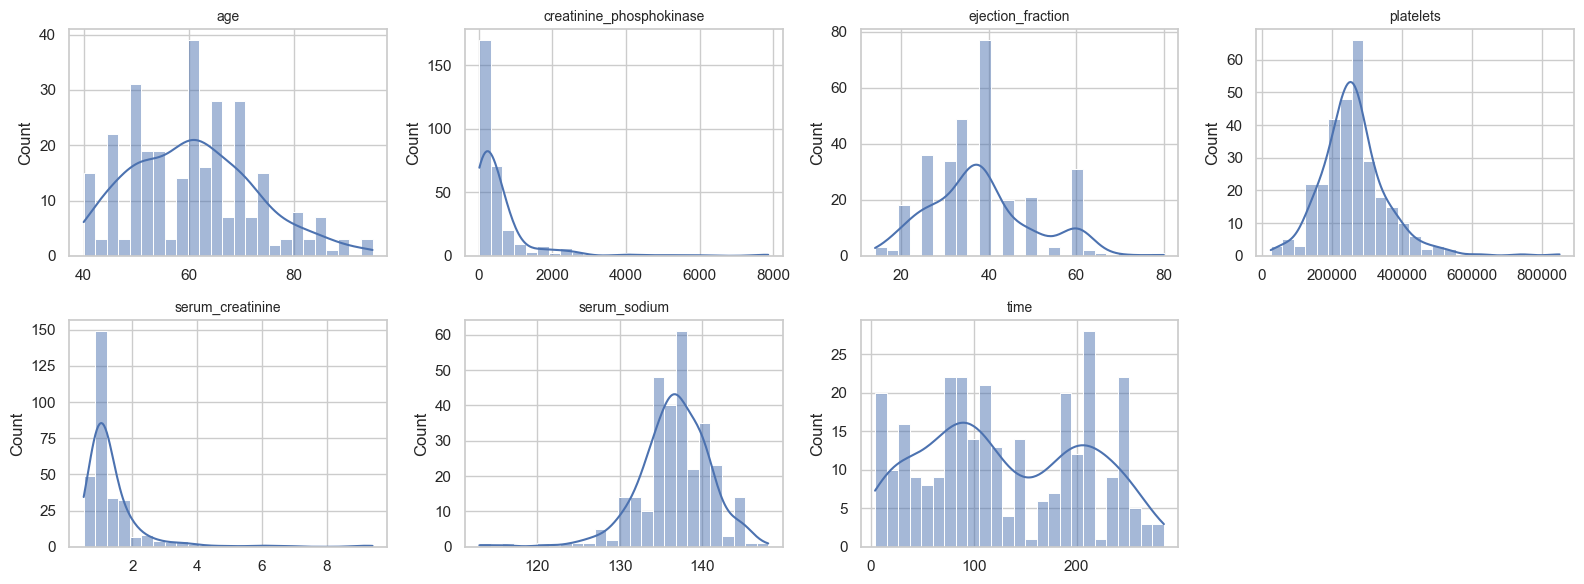

In [6]:
continuous_preview = [
    "age", "creatinine_phosphokinase", "ejection_fraction",
    "platelets", "serum_creatinine", "serum_sodium", "time",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.ravel(), continuous_preview):
    sns.histplot(df_raw[col], kde=True, bins=25, color="#4C72B0", ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### 3.4 Korelasi antar variabel

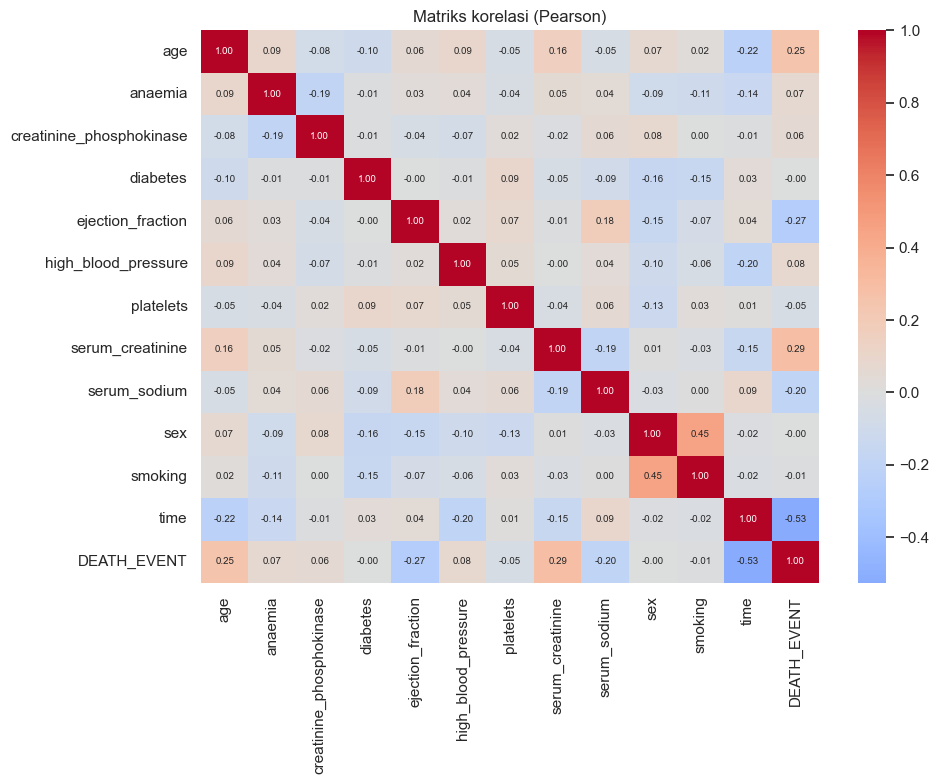

Korelasi terhadap DEATH_EVENT:
time                       -0.527
serum_creatinine            0.294
ejection_fraction          -0.269
age                         0.254
serum_sodium               -0.195
high_blood_pressure         0.079
anaemia                     0.066
creatinine_phosphokinase    0.063
platelets                  -0.049
smoking                    -0.013
sex                        -0.004
diabetes                   -0.002
Name: DEATH_EVENT, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_raw.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriks korelasi (Pearson)")
plt.tight_layout()
plt.show()

print("Korelasi terhadap DEATH_EVENT:")
print(df_raw.corr(numeric_only=True)[target_col_raw].drop(target_col_raw)
        .sort_values(key=abs, ascending=False).round(3))

**Temuan:** tidak ada pasangan fitur dengan korelasi tinggi (semua |r| < 0.5), sehingga tidak ada
fitur yang perlu dibuang karena redundansi. Prediktor paling berkorelasi dengan target adalah
`time`, `serum_creatinine`, dan `ejection_fraction`.

> **Catatan mengenai `time`:** kolom ini adalah lama masa follow-up (hari). Korelasinya dengan
> target sangat kuat karena pasien yang meninggal secara alami memiliki periode follow-up yang
> lebih pendek — jadi sebagian informasinya bersifat *look-ahead*. Kolom ini **tetap
> dipertahankan** agar konsisten dengan definisi dataset UCI dan literatur pembandingnya, namun
> perlu diingat bahwa metrik model akan terlihat optimistis karenanya.

## 4. Kolom target dan asumsinya

Target dideteksi otomatis oleh `automate.detect_target()` dengan urutan prioritas:

1. kolom yang dioper eksplisit lewat argumen `--target` (divalidasi terhadap dataframe);
2. pencocokan nama terhadap daftar kata kunci umum
   (`death_event`, `target`, `label`, `class`, `outcome`, `diagnosis`, `y`);
3. *fallback*: kolom terakhir — konvensi yang hampir universal pada dataset tabular.

**Asumsi yang diambil untuk dataset ini:** kolom **`death_event`** (nama asli `DEATH_EVENT`,
dinormalisasi menjadi huruf kecil) adalah target. Kolom ini cocok pada aturan (2), berisi nilai
biner 0/1, dan merupakan kolom terakhir — jadi aturan (2) dan (3) sama-sama menunjuk kolom yang
sama. Seluruh kolom lain diperlakukan sebagai fitur.

In [8]:
df_std = automate.basic_cleaning(automate.standardize_columns(df_raw))
target_col = automate.detect_target(df_std)

print("Nama kolom setelah distandarkan:", list(df_std.columns))
print("Target terdeteksi              :", repr(target_col))
print("Jenis tugas                    :",
      "klasifikasi" if automate.is_classification(df_std[target_col]) else "regresi")

[target] detected by name match: 'death_event'
Nama kolom setelah distandarkan: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'death_event']
Target terdeteksi              : 'death_event'
Jenis tugas                    : klasifikasi


## 5. Keputusan preprocessing dan alasannya

| Langkah | Keputusan | Alasan |
|---|---|---|
| **Nama kolom** | Distandarkan menjadi `snake_case` huruf kecil (`DEATH_EVENT` → `death_event`) | Hanya perubahan kosmetik; menghindari salah ketik huruf besar/kecil di tahap training dan serving. Tidak ada kolom yang di-*rename* secara semantik. |
| **Baris duplikat** | Dihapus | Duplikat membuat bobot sampel menjadi ganda dan bisa membocorkan baris identik ke kedua split. (Dataset ini: 0 duplikat.) |
| **Kolom kosong total** | Dihapus | Tidak membawa informasi apa pun. (Dataset ini: tidak ada.) |
| **Baris tanpa label** | Dihapus | Tidak dapat dipakai untuk *supervised learning*. (Dataset ini: tidak ada.) |
| **Missing value — numerik kontinu** | Imputasi **median** | Lebih tahan terhadap *outlier* dan sebaran miring dibandingkan mean (lihat `creatinine_phosphokinase`). |
| **Missing value — biner/kategorikal** | Imputasi **modus** | Median/mean tidak bermakna untuk nilai indikator maupun label kategori. |
| **Fitur kategorikal** | **One-Hot Encoding** (`drop="if_binary"`, `handle_unknown="ignore"`) | Tidak mengasumsikan urutan antar kategori; `drop="if_binary"` mencegah kolom redundan; `handle_unknown` membuat inferensi aman saat muncul kategori baru. (Dataset ini: tidak ada kolom kategorikal bertipe teks.) |
| **Fitur numerik kontinu** | **StandardScaler** | Rentang antar fitur berbeda beberapa orde besaran; penskalaan diperlukan oleh model berbasis jarak/gradien (Logistic Regression, SVM, KNN, NN) dan tidak merugikan model berbasis pohon. |
| **Fitur biner 0/1** | **Tidak diskalakan**, hanya diimputasi | Sudah berada pada skala yang sebanding; menskalakan indikator hanya mengaburkan interpretasi tanpa manfaat. Inilah maksud "menskalakan hanya bila tepat". |
| **Outlier** | **Dipertahankan** | Nilai laboratorium ekstrem (mis. `creatinine_phosphokinase` = 7861) adalah kondisi klinis nyata, bukan galat entri. Membuangnya akan menghapus kasus berisiko tinggi yang justru ingin diprediksi. |
| **Urutan split vs transformasi** | *Split dulu*, `fit` **hanya pada data train**, lalu `transform` pada train & test | Mencegah **kebocoran data**: statistik imputer dan scaler tidak boleh melihat data uji. |
| **Rasio split** | 80% train / 20% test, **stratified**, `random_state=42` | Rasio standar; stratifikasi menjaga proporsi kelas 68/32 di kedua sisi; seed tetap membuat hasil dapat direproduksi. |
| **Penyeimbangan kelas** | Tidak dilakukan di sini | Merupakan keputusan pemodelan, bukan preprocessing; data hasil olahan tetap netral untuk dipakai berbagai strategi. |

## 6. Menjalankan pipeline preprocessing

Satu pemanggilan `automate.preprocess()` menjalankan seluruh langkah di tabel atas:
pembersihan → deteksi target → pengelompokan tipe fitur → *stratified split* →
`fit` transformer pada train → `transform` pada train & test.

In [9]:
result = automate.preprocess(
    df_raw,
    target=None,                  # None = deteksi otomatis
    test_size=automate.TEST_SIZE, # 0.2
    random_state=RANDOM_STATE,    # 42
)

train_df = result["train"]
test_df = result["test"]
preprocessor = result["preprocessor"]
metadata = result["metadata"]

print(json.dumps(metadata, indent=2))

[target] detected by name match: 'death_event'
[features] continuous=7 binary=5 categorical=0
{
  "target": "death_event",
  "task": "classification",
  "random_state": 42,
  "test_size": 0.2,
  "n_rows_raw": 299,
  "n_rows_train": 239,
  "n_rows_test": 60,
  "feature_groups": {
    "continuous": [
      "age",
      "creatinine_phosphokinase",
      "ejection_fraction",
      "platelets",
      "serum_creatinine",
      "serum_sodium",
      "time"
    ],
    "binary": [
      "anaemia",
      "diabetes",
      "high_blood_pressure",
      "sex",
      "smoking"
    ],
    "categorical": []
  },
  "output_features": [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
  ]
}


In [10]:
print("Bentuk train :", train_df.shape)
print("Bentuk test  :", test_df.shape)
train_df.head()

Bentuk train : (239, 13)
Bentuk test  : (60, 13)


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking,death_event
115,-0.269050,-0.200735,0.176528,-1.004722,-0.360437,0.559915,-0.467847,1.0,0.0,0.0,0.0,0.0,0
23,-0.706883,-0.534318,1.847425,1.051685,-0.544467,-0.345802,-1.359167,0.0,1.0,0.0,1.0,0.0,0
0,1.219579,-0.020580,-1.494369,0.013401,0.467698,-1.477949,-1.591685,0.0,0.0,1.0,1.0,0.0,1
247,0.256348,-0.455129,-1.076645,-0.178127,0.927773,-0.345802,1.121028,0.0,0.0,0.0,1.0,0.0,0
194,-1.407414,-0.020580,-1.494369,-1.387778,0.191653,-0.345802,0.681827,0.0,0.0,1.0,1.0,0.0,1


### 6.1 Verifikasi hasil

In [11]:
target = metadata["target"]

checks = {
    "tidak ada missing value pada train": int(train_df.isna().sum().sum()) == 0,
    "tidak ada missing value pada test": int(test_df.isna().sum().sum()) == 0,
    "kolom train & test identik": list(train_df.columns) == list(test_df.columns),
    "jumlah baris terjaga": len(train_df) + len(test_df) == len(df_raw),
    "seluruh fitur bertipe numerik": train_df.drop(columns=[target])
        .select_dtypes(include=np.number).shape[1] == train_df.shape[1] - 1,
}
for name, ok in checks.items():
    print(f"{'OK  ' if ok else 'GAGAL'} — {name}")

print("\nProporsi kelas (stratifikasi terjaga):")
print(pd.DataFrame({
    "train": train_df[target].value_counts(normalize=True).sort_index().round(3),
    "test": test_df[target].value_counts(normalize=True).sort_index().round(3),
}))

OK   — tidak ada missing value pada train
OK   — tidak ada missing value pada test
OK   — kolom train & test identik
OK   — jumlah baris terjaga
OK   — seluruh fitur bertipe numerik

Proporsi kelas (stratifikasi terjaga):
             train   test
death_event              
0            0.678  0.683
1            0.322  0.317


In [12]:
# Fitur kontinu kini ber-mean ~0 dan std ~1 pada data train (efek StandardScaler),
# sementara fitur biner tetap pada nilai 0/1 aslinya.
groups = metadata["feature_groups"]
summary = train_df[groups["continuous"] + groups["binary"]].agg(["mean", "std", "min", "max"]).T.round(3)
summary["kelompok"] = ["kontinu (diskalakan)"] * len(groups["continuous"]) + \
                      ["biner (tidak diskalakan)"] * len(groups["binary"])
summary

,mean,std,min,max,kelompok
age,0.000,1.002,-1.845,2.971,kontinu (diskalakan)
creatinine_phosphokinase,0.000,1.002,-0.574,7.185,kontinu (diskalakan)
ejection_fraction,0.000,1.002,-1.912,3.518,kontinu (diskalakan)
platelets,-0.000,1.002,-2.405,5.910,kontinu (diskalakan)
serum_creatinine,-0.000,1.002,-0.821,7.369,kontinu (diskalakan)
serum_sodium,0.000,1.002,-5.327,2.598,kontinu (diskalakan)
time,0.000,1.002,-1.592,1.974,kontinu (diskalakan)
anaemia,0.448,0.498,0.000,1.000,biner (tidak diskalakan)
diabetes,0.448,0.498,0.000,1.000,biner (tidak diskalakan)
high_blood_pressure,0.372,0.484,0.000,1.000,biner (tidak diskalakan)


## 7. Menyimpan hasil ke `data/processed/`

Berkas yang dihasilkan:

| Berkas | Isi |
|---|---|
| `heart_failure_preprocessed.csv` | Seluruh data hasil preprocessing (train + test digabung) — siap dipakai untuk training |
| `train.csv` | Split latih (80%), fitur + target |
| `test.csv` | Split uji (20%), fitur + target |
| `preprocessor.joblib` | `ColumnTransformer` yang sudah di-*fit* (hanya pada train) untuk dipakai saat inferensi |
| `metadata.json` | Nama target, kelompok fitur, ukuran split, dan seed |

In [13]:
paths = automate.save_outputs(result, PROJECT_ROOT / "data" / "processed")
for name, path in paths.items():
    print(f"{name:13s} -> {path.relative_to(PROJECT_ROOT)}  ({path.stat().st_size:,} bytes)")

full          -> data\processed\heart_failure_preprocessed.csv  (48,535 bytes)
train         -> data\processed\train.csv  (38,823 bytes)
test          -> data\processed\test.csv  (9,866 bytes)
preprocessor  -> data\processed\preprocessor.joblib  (3,221 bytes)
metadata      -> data\processed\metadata.json  (803 bytes)


In [14]:
# Verifikasi ulang: baca kembali berkas yang disimpan.
reloaded = pd.read_csv(paths["full"])
print("Bentuk berkas gabungan :", reloaded.shape)
print("Missing value          :", int(reloaded.isna().sum().sum()))
reloaded.head()

Bentuk berkas gabungan : (299, 13)
Missing value          : 0


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking,death_event
0,-0.269050,-0.200735,0.176528,-1.004722,-0.360437,0.559915,-0.467847,1.0,0.0,0.0,0.0,0.0,0
1,-0.706883,-0.534318,1.847425,1.051685,-0.544467,-0.345802,-1.359167,0.0,1.0,0.0,1.0,0.0,0
2,1.219579,-0.020580,-1.494369,0.013401,0.467698,-1.477949,-1.591685,0.0,0.0,1.0,1.0,0.0,1
3,0.256348,-0.455129,-1.076645,-0.178127,0.927773,-0.345802,1.121028,0.0,0.0,0.0,1.0,0.0,0
4,-1.407414,-0.020580,-1.494369,-1.387778,0.191653,-0.345802,0.681827,0.0,0.0,1.0,1.0,0.0,1


## 8. Uji kewajaran cepat (opsional)

Bukan bagian dari preprocessing — hanya memastikan data hasil olahan benar-benar dapat langsung
dipakai melatih model. Pemodelan dan *tuning* yang sesungguhnya dilakukan pada tahap berikutnya.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, pred):.3f}")
print(f"F1-score : {f1_score(y_test, pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1]):.3f}")

Accuracy : 0.817
F1-score : 0.667
ROC-AUC  : 0.861


## 9. Ringkasan

- **Dataset:** `heart_failure_clinical_records_dataset.csv` — 299 baris, 12 fitur, 1 target biner.
- **Target:** `death_event` (asal `DEATH_EVENT`), terdeteksi otomatis lewat pencocokan nama dan
  dikonfirmasi oleh aturan *fallback* kolom terakhir.
- **Kualitas data:** tanpa missing value dan tanpa duplikat; jalur imputasi tetap disediakan agar
  pipeline tetap aman bila data mentah diperbarui.
- **Preprocessing:** nama kolom distandarkan → 7 fitur kontinu diimputasi median + `StandardScaler`
  → 5 fitur biner hanya diimputasi modus → kolom kategorikal (bila ada) di-*one-hot encode*.
- **Split:** 80/20 *stratified*, `random_state=42`, transformer di-*fit* hanya pada data train
  sehingga bebas kebocoran data.
- **Output:** `data/processed/` berisi `heart_failure_preprocessed.csv`, `train.csv`, `test.csv`,
  `preprocessor.joblib`, dan `metadata.json`.

Menjalankan ulang seluruh proses tanpa notebook:

```bash
python experiment/automate.py
```

Perintah tersebut menjalankan fungsi-fungsi yang persis sama dan menghasilkan berkas yang identik
bit-per-bit karena seluruh langkah acak memakai seed tetap.